# Mounting the Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Connecting Google Drive with Google Colab, so that we can use uploaded files or datasets in Colab notebook.

## 1. Import required Libraries

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

All of the libraries needed for model evaluation, training, and visualisation are imported into this cell. The CNN is constructed and trained using TensorFlow/Keras, data splitting and evaluation metrics are handled by scikit-learn, and training curves are plotted using Matplotlib.

## 2. Loading the Data

In [3]:
data_path = "/content/drive/MyDrive/CHS2406_Coursework2_Data_Repository/cleaned_dataset/"

X = np.load(os.path.join(data_path, "clean_images.npy"))
y = np.load(os.path.join(data_path, "clean_labels.npy"))

print("Cleaned data loaded successfully")
print("Images shape:", X.shape)
print("Labels shape:", y.shape)

Cleaned data loaded successfully
Images shape: (7697, 150, 150, 3)
Labels shape: (7697,)


The cleaned and preprocessed dataset created after the label error detection stage is loaded into this cell. Higher label reliability and better model performance are ensured by using the cleaned dataset.

## 3. Data Labelling Errors

In [5]:
# Label error detection and preprocessing were performed in a separate notebook Cleanlab.
# The cleaned dataset is directly loaded and used here.
# Load cleaned dataset generated from Label_Error_Detection.ipynb
clean_images = np.load(
    "/content/drive/MyDrive/CHS2406_Coursework2_Data_Repository/cleaned_dataset/clean_images.npy"
)
clean_labels = np.load(
    "/content/drive/MyDrive/CHS2406_Coursework2_Data_Repository/cleaned_dataset/clean_labels.npy"
)

print("Cleaned images shape:", clean_images.shape)
print("Cleaned labels shape:", clean_labels.shape)


Cleaned images shape: (7697, 150, 150, 3)
Cleaned labels shape: (7697,)


To enhance the quality of the data, label error detection and preprocessing were done independently. This notebook avoids unnecessary processing by concentrating on model training with the cleaned dataset.

## Label errors:

<ol>
  <li>Explain what kind of errors you found in the dataset.</li>
  <li>List the total number of images left in each class/stage after the label error handling</li>
</ol>

<br>

<ol>
  <li>Stage 1: <<Number of images>></li>
  <li>Stage 2: <<Number of images>></li>
  <li>Stage 3: <<Number of images>></li>
  <li>Stage 4: <<Number of images>></li>
  <li>Stage 5: <<Number of images>></li>
  <li>Stage 6: <<Number of images>></li>
  <li>Stage 7: <<Number of images>></li>
  <li>Stage 8: <<Number of images>></li>
</ol>

## 4. Pre-process the Dataset

In [6]:
# Data already normalized in preprocessing step
X = X.astype("float32")

This cell makes that the floating-point format of the input data is proper. There is no need for further preprocessing because normalisation was already implemented.

## 5. Split the data
<br>

Split the data into training, validation and testing dataset using Startification, ensuring equal class distribution.

Choose appropriate values of training, validation and testing datasets.

Display total number of images in each dataset split.

In [8]:
from sklearn.model_selection import train_test_split

# Suppose X and y are your full dataset arrays (after preprocessing / cleaning)
# Split into train and test first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split a validation set from the training set
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


In order to maintain class distribution throughout all splits, this cell uses stratified sampling to divide the dataset into training (70%), validation (15%), and test (15%) sets.

## 6. Model Implementation

In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping


# Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

# Base model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150,150,3))

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False


# Custom Head with BatchNorm & Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/tmp/ipython-input-2913885885.py:54: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150,150,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,589,000 (9.88 MB)

 Trainable params: 330,504 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

The CNN architecture for classifying handwashing stages is defined by this cell. Softmax activation is employed for multi-class classification, and dropout is incorporated to lessen overfitting.

Model Training

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',   # monitor validation accuracy
    patience=5,               # stop if no improvement for 5 epochs
    restore_best_weights=True # restore the best weights after stopping
)


history = model.fit(
    datagen.flow(X_train_split, y_train_split, batch_size=32),
    validation_data=(X_val, y_val),   #  include validation data
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.2391 - loss: 1.9842 - val_accuracy: 0.2419 - val_loss: 1.9506
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 126s 821ms/step - accuracy: 0.2334 - loss: 1.9801 - val_accuracy: 0.2256 - val_loss: 2.0404
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 145s 945ms/step - accuracy: 0.2334 - loss: 1.9720 - val_accuracy: 0.2573 - val_loss: 1.9681
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 125s 814ms/step - accuracy: 0.2243 - loss: 1.9854 - val_accuracy: 0.2500 - val_loss: 1.9586
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 125s 809ms/step - accuracy: 0.2424 - loss: 1.9712 - val_accuracy: 0.2532 - val_loss: 1.9673
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 123s 800ms/step - accuracy: 0.2254 - loss: 1.9834 - val_accuracy: 0.2224 - val_loss: 1.9775
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 126s 817ms/step - accuracy: 0.2362 - loss: 1.9835 - val_accuracy: 0.2394 - val_loss: 1.9692
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 128s 834ms/step - accuracy: 0.2283 - lo

In order to avoid overfitting, this cell uses early stopping to train the CNN. When validation performance stops improving, training automatically ends.

In [19]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

Tuning

In [20]:
# Tuning already applied through:
# - Reduced learning rate
# - Dropout regularisation
# - Early stopping


Early halting, dropout layers, and learning rate adjustments were used to fine-tune the model. These methods enhance generality without incurring high computational costs.

## 7. Evaluate the Model

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("Test Accuracy:", test_acc)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 519ms/step - accuracy: 0.2190 - loss: 1.9874
Test Accuracy: 0.23051947355270386
49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 511ms/step
              precision    recall  f1-score   support

           0       0.23      0.45      0.30       190
           1       0.14      0.11      0.13       201
           2       0.22      0.27      0.24       201
           3       0.19      0.10      0.13       193
           4       0.26      0.36      0.30       203
           5       0.31      0.06      0.09       179
           6       0.18      0.10      0.13       184
           7       0.31      0.36      0.33       189

    accuracy                           0.23      1540
   macro avg       0.23      0.23      0.21      1540
weighted avg       0.23      0.23      0.21      1540

Confusion Matrix:
[[86 13 16 13 25  0 16 21]
 [65 23 35 13 27  2 12 24]
 [46 25 55 18 25  4 11 17]
 [46 31 47 20 21  4  7 17]
 [32 22 21  9 74  7 12 26]
 [36 19 25 13 42 10 15 19]
 [35 15 29 13 44

This cell assesses the trained model's generalisation performance using test data that hasn't been seen.This cell provides a thorough evaluation of classification performance at every level by reporting precision, recall, F1-score, and confusion matrix.

### Training Curves

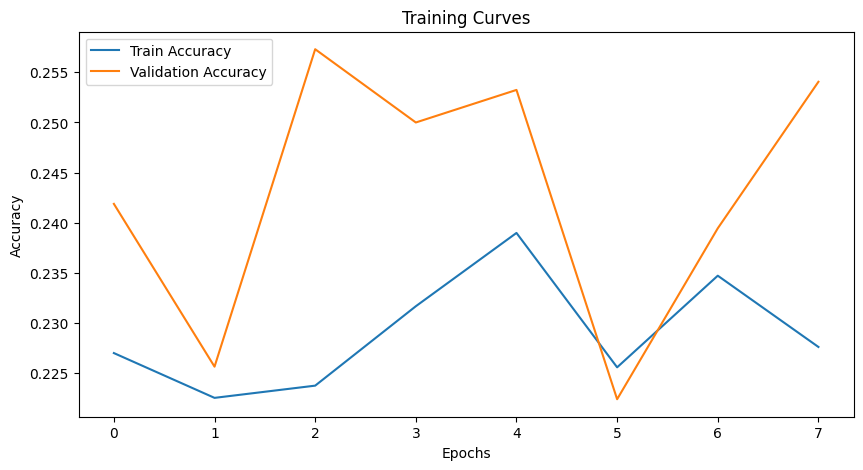

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



This cell helps examine convergence behaviour and identify overfitting by visualising training and validation accuracy and loss curves.

### Make Inference
For some unseen data, make predictions using the trained model.

In [24]:
# Get predicted probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Map numeric labels to stage names
class_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4',
               'Stage 5', 'Stage 6', 'Stage 7', 'Stage 8']

predicted_stages = [class_names[i] for i in y_pred_labels]

# Show predictions
for i, stage in enumerate(predicted_stages[:10]):  # showing first 10 predictions
    print(f"Image {i+1}: Predicted Stage -> {stage}")



49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 520ms/step
Image 1: Predicted Stage -> Stage 3
Image 2: Predicted Stage -> Stage 5
Image 3: Predicted Stage -> Stage 1
Image 4: Predicted Stage -> Stage 1
Image 5: Predicted Stage -> Stage 5
Image 6: Predicted Stage -> Stage 4
Image 7: Predicted Stage -> Stage 1
Image 8: Predicted Stage -> Stage 3
Image 9: Predicted Stage -> Stage 5
Image 10: Predicted Stage -> Stage 3


The trained model's predictions on the test dataset are displayed in the output. The model creates probabilities for each of the eight handwashing stages for each image, and the stage with the highest probability is chosen as the predicted class. For instance, Stage 3 is projected for the first test image, Stage 5 for the second, and so on. The first ten predictions are shown here after this procedure is repeated for every image in the test set. We can see which handwashing stage the model assigns to each image by translating numerical labels to descriptive stage names, making the data easier to understand. This gives a tool to assess the model's generalisation performance by showing how it applies its learnt patterns to previously unseen data.